In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === 1. Загрузка данных ===
file_path = "ml2/ml_outputs_v1/test_predictions.csv"  # путь к файлу

df = pd.read_csv(file_path)

print("Колонки:", df.columns)
print("\nПервые строки:")
print(df.head())

# === 2. Выделение данных ===
y_true = df["y_true"]
y_pred = df["y_pred"]

# === 3. Расчет метрик ===
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# === 4. Вывод результатов ===
print("\n=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ МОДЕЛИ ===")
print(f"MAE  (средняя абсолютная ошибка): {mae:.4f}")
print(f"MSE  (среднеквадратичная ошибка): {mse:.4f}")
print(f"RMSE (корень из MSE): {rmse:.4f}")
print(f"R²   (коэффициент детерминации): {r2:.4f}")

# === 5. Дополнительный анализ ошибок ===
df["error"] = y_true - y_pred
df["abs_error"] = np.abs(df["error"])

print("\n=== АНАЛИЗ ОШИБОК ===")
print(f"Средняя ошибка: {df['error'].mean():.4f}")
print(f"Максимальная ошибка: {df['abs_error'].max():.4f}")
print(f"Минимальная ошибка: {df['abs_error'].min():.4f}")

# === 6. Сохранение результатов (опционально) ===
df.to_csv("test_predictions_with_errors.csv", index=False)

print("\nФайл с ошибками сохранен: test_predictions_with_errors.csv")

Колонки: Index(['y_true', 'y_pred', 'dataset_id'], dtype='object')

Первые строки:
   y_true     y_pred dataset_id
0    94.0  82.913333      dt010
1    73.0  64.206667      dt010
2    51.0  67.576667      dt010
3    77.0  78.820000      dt010
4    93.0  81.286667      dt010

=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ МОДЕЛИ ===
MAE  (средняя абсолютная ошибка): 20.8417
MSE  (среднеквадратичная ошибка): 763.1442
RMSE (корень из MSE): 27.6251
R²   (коэффициент детерминации): 0.1922

=== АНАЛИЗ ОШИБОК ===
Средняя ошибка: -9.8432
Максимальная ошибка: 73.0500
Минимальная ошибка: 0.0333

Файл с ошибками сохранен: test_predictions_with_errors.csv


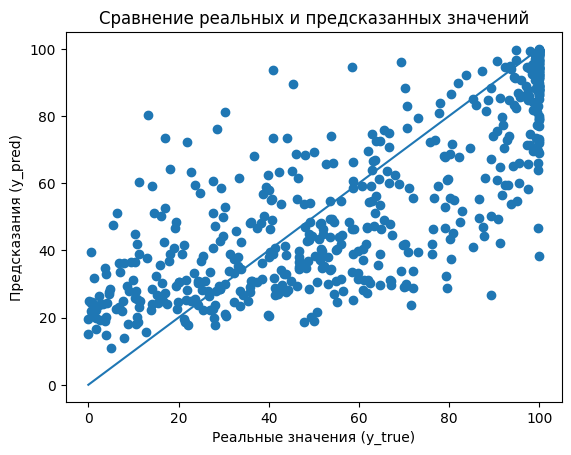

In [2]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_true, y_pred)
plt.xlabel("Реальные значения (y_true)")
plt.ylabel("Предсказания (y_pred)")
plt.title("Сравнение реальных и предсказанных значений")

# идеальная линия
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()])

plt.show()

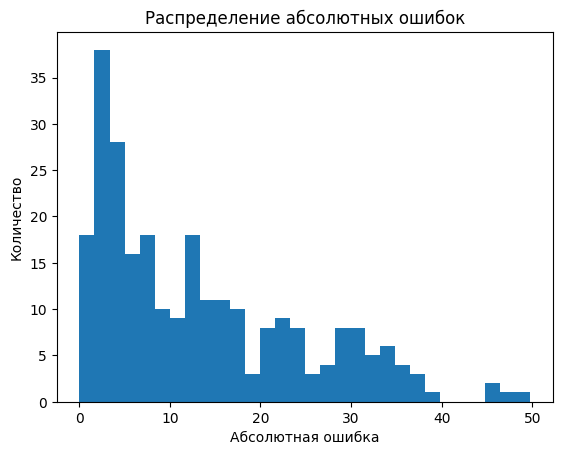

In [10]:
plt.figure()
plt.hist(df["abs_error"], bins=30)
plt.title("Распределение абсолютных ошибок")
plt.xlabel("Абсолютная ошибка")
plt.ylabel("Количество")
plt.show()

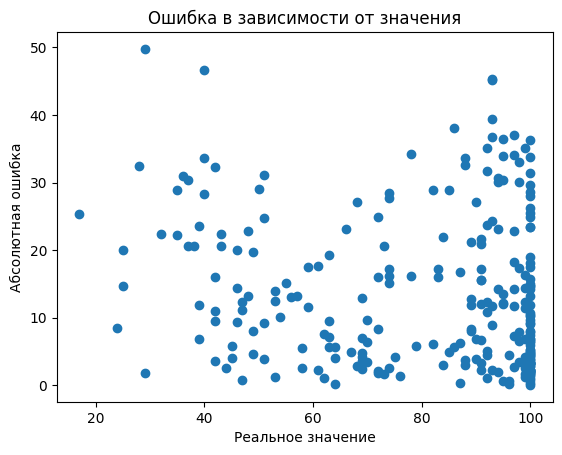

In [11]:
plt.figure()
plt.scatter(y_true, df["abs_error"])
plt.xlabel("Реальное значение")
plt.ylabel("Абсолютная ошибка")
plt.title("Ошибка в зависимости от значения")
plt.show()